# Neural Networks - Optimizers

## 1. The Limits of Gradient Descent

- Gradient descent works well on assumption: Loss space is *simple enough to go downhill*.
  - It has no memory
  - It has no understanding of terrain
  - Simply show slope -> move downhill.
- In reality, billions of params -> **Trajectory**.

> Model = spacecraft, loss landscape = terrain, params = spacecraft position, gradient = direction sensor, gradient descent = navigation system -> **Optimiser** tells how large a step is, speed, whether to remember previous movement.

### Ill-Conditioning

> **Ill-conditioning**: like a long narrow valley, one direction is flat, one is steep.

e.g.,

$$
L = x^2 + 100y^2 \\
\Rightarrow \frac{\partial L}{\partial x} = 2x, \frac{\partial L}{\partial y} = 200y
$$

Matplotlib is building the font cache; this may take a moment.


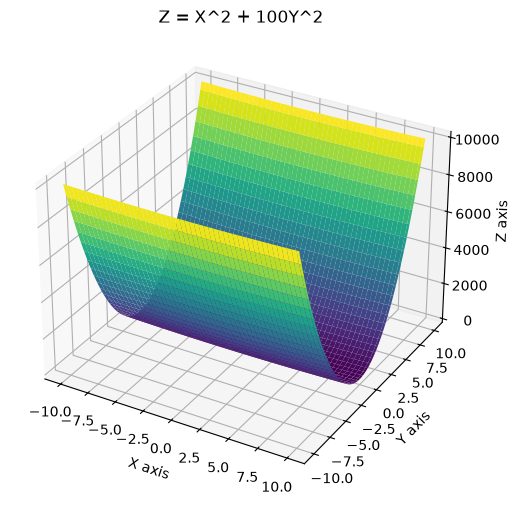

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)

Z = X**2 + 100*Y**2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Z = X^2 + 100Y^2')

plt.show();

- Since y has huge curvature -> update y is too aggressive.
- learning rate = 0.01 works for x but not for y.

In [3]:
def loss(x, y):
    return x**2 + 100*y**2

def gradient(x, y):
    return np.array([2*x, 200*y])

x, y = 5, 5
lr = .01

trajectory = []

for i in range(100):
    trajectory.append((x, y))
    grad = gradient(x, y)
    x -= lr*grad[0]
    y -= lr*grad[1]

print(x, y)

0.6630977794737659 5.0


### Curvature

> **Curvature**: How quickly does the slop change?

- Second derivative: $L''$
- Use Hessian matrix for NNs -> describe the shape of the landscape.

$$
H = \begin{bmatrix}
\frac{\partial^2 L}{\partial x^2} & \frac{\partial^2 L}{\partial x \partial y} \\
\frac{\partial^2 L}{\partial y \partial x} & \frac{\partial^2 L}{\partial y^2}
\end{bmatrix}
$$

### Taylor Expansion: Local approximation

- Smooth function moves around $\theta$ like a quadratic:

$$
L(\theta + \Delta) \approx L(\theta) + \nabla L(\theta)^T\Delta + \frac{1}{2}\Delta^TH\Delta
$$

- $L(\theta)$: current loss
- $\nabla L(\theta)^T\Delta$: slope
- $\frac{1}{2}\Delta^TH\Delta$: curvature

### Plateaus

> **Plateaus**: region where gradients are tiny

- Due to:
  - Saturation
  - Bad initialisation
  - Symmetry
  - Certain regions of the loss surface

e.g., $f(x) = 0.001x^2 \Rightarrow f'(x) = 0.002x$

### Saddle Points

> **Saddle point**: minimum in one direction, maximum in another. In NNs, it's usually a bigger problem than local minima.

e.g., $f(x,y) = x^2 - y^2$. The saddle point is $(0, 0)$, where $\nabla f(0, 0) = 0$.

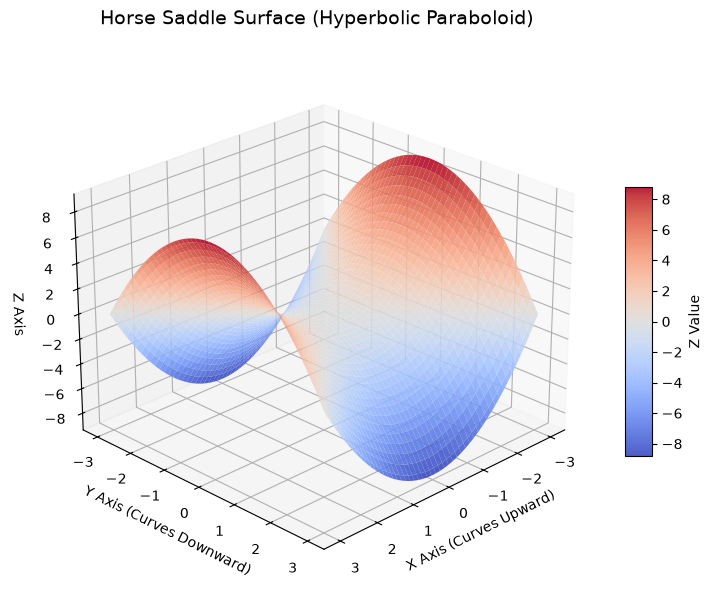

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

Z = X**2 - Y**2

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none', alpha=0.9)

ax.set_title('Horse Saddle Surface (Hyperbolic Paraboloid)', fontsize=14, pad=20)
ax.set_xlabel('X Axis (Curves Upward)')
ax.set_ylabel('Y Axis (Curves Downward)')
ax.set_zlabel('Z Axis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Z Value')

ax.view_init(elev=25, azim=45)
plt.show();

### Exploding Directions

- Exploding gradients
- Unstable traing
- Gradient clipping

### Why Optimizers Exist

- Each optimizer solves a mathematical problem.

| Problem             | Solution                         |
| ------------------- | -------------------------------- |
| Oscillation         | Momentum                         |
| Different curvature | Adaptive learning rates          |
| Noisy gradients     | Moving averages                  |
| Bad conditioning    | Preconditioning                  |
| Huge models         | Memory-efficient optimizers      |
| Expensive curvature | Approximate second-order methods |


## 2. Loss Landscape Geometry

- **Gradient** tells you which direction, **but not**:
  - the hill is steep or gentle
  - valley is narrow ahead
  - you are approaching a cliff
  - the surface is almost flat
- That's why we need **curvature** to tell how fast is the gradient changing.
- Let's go back to **Hessian**:
  - top-left: curvature if only move in x
  - bottom-right: curvature if only move in y
  - Off-diagonal terms: If we move in x, does the slope in y change? How related are x and y.

$$
H = \begin{bmatrix}
\frac{\partial^2 L}{\partial x^2} & \frac{\partial^2 L}{\partial x \partial y} \\
\frac{\partial^2 L}{\partial y \partial x} & \frac{\partial^2 L}{\partial y^2}
\end{bmatrix}
$$

- Instead of analysing millions of interacting params, we think of the landscape as many independent directions -> **Eigenvectors of Hessian**.
  - Along each eigenvector, the surface behaves like an independent quadratic curve.
  - The associated eigenvalue tells you the curvature in that direction.

e.g., Circular bowl $z = x^2 + y^2$ Both eigenvalues are identical. The curvature is perfectly uniform in all directions, creating a symmetrical, round dish. Elongated bowl $z = x^2 + 4y^2$ One eigenvalue is larger than the other. This creates a steep curvature along one eigenvector direction and a gentle, stretched-out curvature along the other, forming a trough or U-shaped valley.

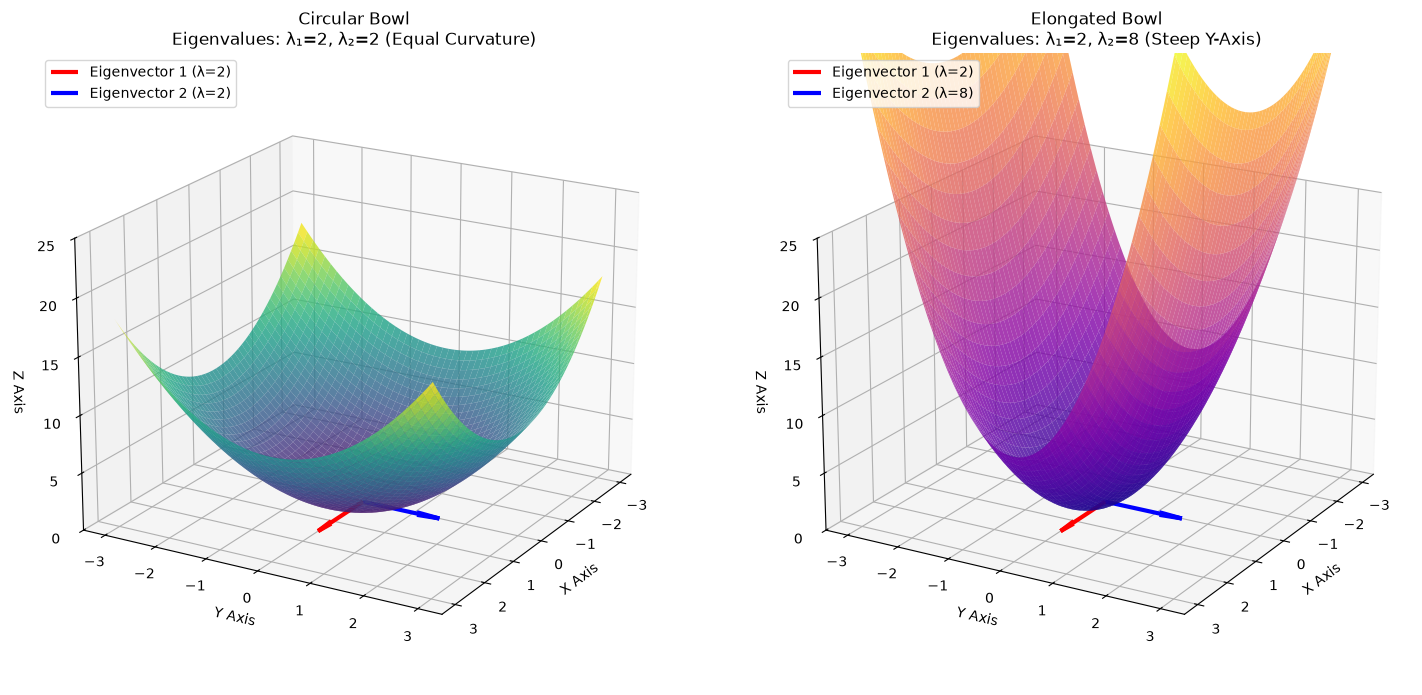

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

Z_circular = X**2 + Y**2       # Hessian eigenvalues: [2, 2]
Z_elongated = X**2 + 4*(Y**2)  # Hessian eigenvalues: [2, 8]

fig = plt.figure(figsize=(15, 7))

# --- LEFT: CIRCULAR BOWL ---
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z_circular, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_title('Circular Bowl\nEigenvalues: λ₁=2, λ₂=2 (Equal Curvature)', fontsize=12)

# Plot Eigenvectors at the bottom (0, 0, 0)
# v1 =, v2 = [0, 1]
ax1.quiver(0, 0, 0, 1.5, 0, 0, color='red', linewidth=3, label='Eigenvector 1 (λ=2)')
ax1.quiver(0, 0, 0, 0, 1.5, 0, color='blue', linewidth=3, label='Eigenvector 2 (λ=2)')

# --- RIGHT: ELONGATED BOWL ---
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z_elongated, cmap='plasma', alpha=0.8, edgecolor='none')
ax2.set_title('Elongated Bowl\nEigenvalues: λ₁=2, λ₂=8 (Steep Y-Axis)', fontsize=12)

# Plot Eigenvectors at the bottom (0, 0, 0)
# v1 = [1, 0] (shallow curve), v2 = [0, 1] (steep curve)
ax2.quiver(0, 0, 0, 1.5, 0, 0, color='red', linewidth=3, label='Eigenvector 1 (λ=2)')
ax2.quiver(0, 0, 0, 0, 1.5, 0, color='blue', linewidth=3, label='Eigenvector 2 (λ=8)')

# Format both plots cleanly
for ax in [ax1, ax2]:
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    ax.set_zlim(0, 25)
    ax.view_init(elev=20, azim=30)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show();

### Condition Number

> Condition number: Rate of max curvature to min curvature, to see the dynamic of the curvature in parameters.

$$
\mathcal{K} = \frac{\lambda_{\max}}{\lambda_{\min}}
$$

- $\lambda_{\max}$: max eigenvalue of Hessian
- $\lambda_{\min}$: min eigenvalue of Hessian

e.g., A Hessian has eigenvalues $\{ 0.1, 100 \}$, $\mathcal{K} = 1000$. A lane allows 100km/h, the other 0.1km/h. One learning rate works for 100km/h but painfully slowly on the 0.1km/h lane. If one learning rate works well in 0.1km/h, then it would explode in 100km/h.

### Convex vs Non-Convex Landscapes

> In convex, local optimum = global optimum. But NNs are not convex. It contains: valleys, ridges, saddles, plateaus, flat regions, sharp regions.

### Anisotropy

> **Anisotropy**: Different directions behave differently.

e.g., a sphere is *isotropic* (each direction is identical), an American football is *anisotropic* (geometry depends on direction).

- Loss landscapes are highly anisotropic, because:
  - Massive param **interactions**
  - **Non-linear** activations
  - **Composition** of layers and non-linear functions
  - **Overparameterisation**: more params than training examples.

### An example of Hessian

$$
L(x,y) = x^2 + 3xy + 2y^2
$$

Hessian:

$$
H = \begin{bmatrix}
    2 & 3 \\
    3 & 4
\end{bmatrix}
$$

In [11]:
def loss(theta):
    x, y = theta
    return x**2 + 3*x*y + 2*y**2

def numerical_hessian(f, theta, eps=1e-5):
    n = len(theta)
    H = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            e_i = np.zeros(n)
            e_j = np.zeros(n)

            e_i[i] = eps
            e_j[j] = eps

            H[i, j] = (
                f(theta + e_i + e_j)
                - f(theta + e_i - e_j)
                - f(theta - e_i + e_j)
                + f(theta - e_i - e_j)
            ) / (4 * eps**2)

    return H

theta = np.array([1.0, 2.0])

H = numerical_hessian(loss, theta)

print(H)

[[2.00000461 2.99999137]
 [2.99999137 4.00000033]]


## 3. Stochastic Optimisation

> In real NNs, we don't compute true gradient of the loss, we use a noisy approximation. Why?

- For $N$ training examples, the total loss is $L(\theta) = \frac{1}{N}\sum_{i = 1}{N}l_i(\theta)$. With $l_i$ := the loss of one example. Then the **true** gradient is:

$$
\nabla L(\theta) = \frac{1}{N}\sum_{i=1}{N}\nabla l_i(\theta)
$$

- To compute the gradient, we compute gradient of every traing example. If we have trillions of tokens -> **IMPOSSIBLE**!

> **Assumption**: The cost of computing the gradient is negligible.

### Three Ways to Compute Gradient

- **Batch gradient descent**: compute gradient of every example.
- **Stochastic gradient descent**: choose one example -> gradient -> noisy.
- **Mini-batch gradient descent**: choose 32/64/256 examples -> gradient.

> When researchers say SGD, they really mean **Mini-batch SGD**.

- Mini-batch gradient descent works because it's like tossing a coin 100 times is closely 0.5 prob of heads, we don't need to toss it 1,000,000 times.
- Gradient becomes **statistical estimator**, a random variable.

$$
G = \nabla L + \epsilon
$$

> **Gradient noise**: randomness in individual gradient estimates, which are average approximately true gradient.

> **Variance**: How much individual gradients fluctuate. Increase batch size reduces noise but it's not always good.

> **Gradient noise** helps escape bad regions.

## 4. Momentum

- Waste, zig-zag problems of gradient descent
- Gradient descent doesn't remember previous layer values. It only cares current value, and gradient of current value.
- Momentum remember previous gradient -> update speed accelerates.
- Like a Heavy ball rolling downhill, it gains speed.
- Add velocity, which stores the previous gradient, into the equation:

$$
v_t = \beta v_{t-1} - (1 - \beta) g_t
$$

where $0 < \beta < 1$. Then update:

$$
x_{t+1} = x_t + v_t
$$

- $\beta$: How much of the previous velocity survives.
- **Memory length**: number of iterations.

$$
\frac{1}{1 - \beta}
$$

e.g., $\beta = 0.9$ -> 10 iterations, $\beta = 0.99$ -> 100 iterations.

### Exponential Moving Average

Recursively compute the velocity:

$$
v_t = \beta v_{t-1} - \eta g_t =...= -\eta(g_t + \beta g_{t-1} + \beta^2g_{t-2} + ...)
$$

> **Exponential Moving Average (EMA)**: Older gradients decay exponentially.

- Oscillation suppression.

In [12]:
import numpy as np

class Momentum:

    def __init__(self, lr=.01, beta=.9):
        self.lr = lr
        self.beta = beta
        self.v = None

    def step(self, params, grads):
        if self.v is None:
            self.v = np.zeros_like(params)

        self.v = self.beta*self.v - self.lr*grads
        params += self.v
        return params

In [13]:
optimiser = Momentum(lr=.01, beta=.9)

for step in range(1000):
    grads = compute_gradient(params)
    params = optimiser.step(params, grads)

NameError: name 'compute_gradient' is not defined

## 5. Nesterov Accelerated Gradient: Looking Ahead Before Stepping

> **Nesterov** computes velocity look-ahead where momentum takes it to. The original momentum compute velocity based on current velocity -> Too late.

- Estimate future position: $x_t + \beta v_{t-1}$
- Then compute: $\nabla L(x_t + \beta v_{t-1})$

> If I continue moving with this current speed, what does the terrain look like?

$$
v_t = \beta v_{t-1} - \eta\nabla L(x_t + \beta v_{t-1})
$$

then:

$$
x_{t+1} = x_t + v_t
$$

- When you have large velocity, Nesterov helps avoid overshoot by checking the slope ahead.
- Nesterov is *faster, less bouncing,smoother, better anticipation*.

> Nesterov is not dominant today, it is only used in simple SGD-based optimisation settings.
> Today, they use Adam.

### Taylor Expansion

First-order Taylor expansion

$$
\nabla L(x + \Delta) \approx \nabla L(x) + H(x)\Delta
$$

For Nesterov, $\Delta = \beta v_{t-1}$, so

$$
\nabla L(x + \beta v) \approx \nabla L(x) + H(x)\beta v
$$

In [14]:
import numpy as np

class Nesterov:

    def __init__(self, lr=.01, beta=.9):
        self.lr = lr
        self.beta = beta
        self.v = None

    def step(self, params, grad_fn):
        if self.v is None:
            self.v = np.zeros_like(params)
        
        lookahead = params + self.beta*self.v

        grads = grad_fn(lookahead)
        self.v = self.beta*self.v - self.lr*grads
        params += self.v
        return params

## 6. Why One Learning Rate Cannot Fit All Parameters

- Different params mean:
  - different slope
  - different curvature

e.g., slope: $\nabla L = [100, 0.01]^T$. Curvature: $H = \begin{bmatrix} 1000 & 0 \\ 0 & 1 \end{bmatrix}$.

Newton step: $\Delta\theta = -H^{-1}g$ with $H^{-1} = \begin{bmatrix} 1/1000 & 0 \\ 0 & 1 \end{bmatrix}$, very small on steep direction, larger on flat direction.

### Coordinate-wise Optimisation

- Every parameter has its own learning rate: $\theta_i = \theta_i - \eta_i g_i$

### Sparse Gradients

> **Sparse gradients**: In word embeddings, not every word is embeddeded -> For those word, gradient = 0.

- Some params receive gradient every iteration, some receive after every thousand iterations -> painful if use the same learning rate.
- *Larger steps* for rarely updated params. -> **Sparse learning**.
- *Smaller steps* for frequent updated params. -> **Dense learning**.

### Matrix form

- Adaptive learning use matrix with **preconditioner** P:

$$
\Delta \theta = -Pg
$$

- **Preconditioner**: Prescales the optimisation problem, make it easier to solve.
- Ideal preconditioner is inverse Hessian $P = H^{-1}$. But Hessian is too huge to store -> **Diagonal preconditioning**: Approximate diagonal only:

$$
P = \begin{bmatrix}
    p_1 & 0 & 0 \\
    0 & p_2 & 0 \\
    0 & 0 & p_3
\end{bmatrix}
$$

- $p_i$: scaling factors.
  - AdaGrad: sum of all past squared gradients
  - RMSProp: exponential moving average of squared gradients
  - Adam: momentum + RMSProp
  - AdaFactor: Memory-efficient approximation
  - Shampoo: Matrix-valued preconditioners
  - Sophia: Curvature-informed approximations

## 7. AdaGrad — Learning from the Past

> Params that have moved a lot should move less in the future.

- Keep track of how much each params have updated. Each param stores:

$$
G_t = \sum_{i=1}^t g_i^2
$$

- Square is for emphasisation and avoid positive/negative cancellations.
- AdaGrad performs:

$$
G_t = G_{t-1} + g_t^2 \\
w_{t+1} = w_{t} - \frac{\eta}{\sqrt{G_t} + \epsilon}g_t
$$

- Unit of $G_t$ is $g^2$ then $\sqrt{G_t}$ makes sense.

> Fatal weakness: AdaGrad keeps growing, never shrink -> learning rate reaches zero, like keep carrying rocks till you slow down.

### Diagonal Matrix form

for $D_t = \text{diag}(\frac{1}{\sqrt{G_{1, t}}}, \frac{1}{\sqrt{G_{2, t}}}, ...)$, update:

$$
\theta_{t+1} = \theta_t - \eta D_tg_t
$$

### The theory behind AdaGrad - Regret Minimisation

> **Regret**: How much worse did I perform than the best fixed decision I could have chosen in hindsight?

$$
\text{Regret}_T = \sum_{t=1}^Tf_t(\theta_t) - \min_{\theta}\sum_{t=1}^Tf_t(\theta)
$$

- A good online algorithm has sublinear regret:

$$
\frac{\text{Regret}_T}{T} \rightarrow 0
$$

In [15]:
import numpy as np

class AdaGrad:

    def __init__(*self, lr=.01, eps=1e-8):
        self.lr = lr
        self.eps = eps
        self.G = None

    def step(self, params, grads):
        if self.G is None:
            self.G = np.zeros_like(params)

        self.G += grads**2
        params -= self.lr * grads / (np.sqrt(self.G) + self.eps)
        return params

## 8. RMSProp - Learning to Forget

> While AdaGrad never forgets. Memory should fade.

- Remember recent history.

### Exponential Forgeting

- Borrow the idea from Exponential Moving Average:

$$
v_t = \beta v_{t-1} + (1 - \beta)g_t^2
$$

- Older gradients smoothly fades away. (instead of just averaging latest k gradients).

### RMSProp Update

- RMS = Root Mean Square

First compute:

$$
v_t = \beta v_{t-1} + (1 - \beta)g_t^2
$$

then update:

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{v_t} + \epsilon}g_t
$$

- Small $\beta$ -> forget quickly
- large $\beta$ -> Remember longer
- Approximate memory length:

$$
\frac{1}{1 - \beta}
$$

Recursion:

$$
v_t = (1 - \beta)\sum_{k=0}^{t-1}\beta^kg_{t-k}^2
$$

In [16]:
import numpy as np

class RMSProp:

    def __init__(self, lr=.001, beta=.9, eps=1e-8):
        self.lr = lr
        self.beta = beta
        self.eps = eps
        self.v = None

    def step(self, params, grads):
        if self.v is None:
            self.v = np.zeros_like(params)
        self.v = self.beta * self.v + (1 - self.beta) * grads**2
        params -= self.lr * grads / (np.sqrt(self.v) + self.eps)
        return params

## 9. Adam from First Principles — Combining Momentum and RMSProp

- Adam = Adaptive Moment Estimation:
  - Adaptive = each param has its own learning rate
  - Moment = statistics of gradient distribution
    - first moment = mean
    - second moment = mean square
- Gradients don't have memory.
- Momentum remembers prev direction $g_t$. -> removes zig-zagging
- RMSProp remembers magnitude $\sqrt{v_t}$. -> rescales steep and shallow directions
- **Adam** = direction + magnitude.

Adam keeps two memories at once.

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)g_t \\
v_t = \beta_2 v_{t-1} + (1 - \beta_2)g_t^2
$$

the update becomes:

$$
\theta_{t+1} = \theta_t -\eta \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

> Adam also has **bias correction** but we leave it out of the equation for now. e.g., $m_0 = v_0 = 0, g_1 = 10, \beta_1 = 0.9$, then $m_1 = (1 - 0.9)*10 = 1$ which is not true -> We need bias correction.

- We need to keep two $\beta$ because direction changes much faster to speed, like driving a car.

### Complete algo

```
Init m0 = 0, v0 = 0

For each iteration
    Compute gradient gt
    update mt = beta1 * m_t-1 + (1 - beta1)gt
    update vt = beta2*v_t-1 + (1 - beta2)gt^2
    update theta <- theta - eta* mt/ (sqrt(vt) + eps)* gt
```

In [19]:
import numpy as np

class Adam:

    def __init__(self, lr=.01, beta1=.9, beta2=.99, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.v = None
    
    def step(sefl, params, grads):
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)

        self.m = self.beta1*self.m + (1 - self.beta1)*grads
        self.v = self.beta2*self.v + (1 - self.beta2)*(grads**2)

        params -= self.lr*grads * self.m / (np.sqrt(self.v) + self.eps)
        return params

### Why Adam works so well

1. Noisy gradients
2. Different param scales
3. Changing optimisation landscape

## 10. Why Adam Needs Bias Correction

- $m_0 = v_0 = 0$ -> but $g_t$ is large -> EMA makes it too small even after some iterations.
- $m_0$ is a fake observation.
- Recursively,

$$
m_t = (1 - \beta)\sum_{i=1}^t\beta^{t-i}g_i
$$

- Weights sum to $1 - \beta^t \rightarrow 1$ for large $t$.
- But it never added to 1 due to the initial $m_0 = 0$.
- Why weight sum = $1 - \beta^t$?

Suppose $g_i = g$, then

$$
m_t = g(1 - \beta)\sum_{i=0}^{t-1}\beta^i = g(1 - \beta)\frac{1 - \beta^t}{1 - \beta} = g(1 - \beta^t)
$$

- So to recover gradient $g$, divide $m_t$ by $(1 - \beta^t)$.

$$
\^{m} = \frac{m_t}{1 - \beta^t}
$$

- Do the same to RMSProp:

$$
\^{v} = \frac{v_t}{1 - \beta_2^t}
$$

- Bias correction reduces overtime, it only matters at the beginning.

### Why not initialise $m_0$ and $v_0$ differently?

Say $m_0 = g_1$

- Same issue when reset
- Don't know what the init value before computing the first gradient
- Asymmetric init.
- Harder to analyse EMA math properties.

<>:26: SyntaxWarning: invalid escape sequence '\h'
<>:26: SyntaxWarning: invalid escape sequence '\h'
C:\Users\PC\AppData\Local\Temp\ipykernel_18752\2429272383.py:26: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(range(1, 51), m_hat_hist, label='Bias-corrected ($\hat{m}$)', color='seagreen')


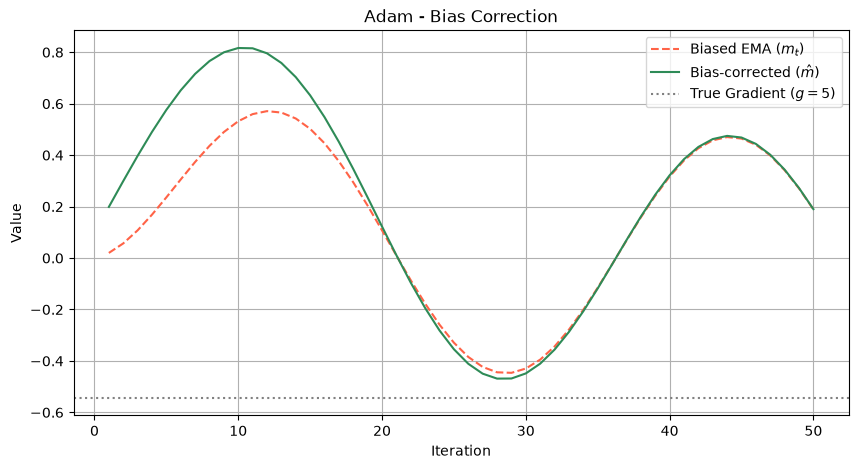

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a constant gradient
g = 5
beta = .9

# Compute the exponential moving average with beta = 0.9
# Compute the bias-corrected estimate m_hat
# Plot both curves for the first 50 iterations

m = 0.0
m_hist = []
m_hat_hist = []

for i in range(1, 51):
    g = np.sin(i/5)
    m = beta*m + (1 - beta)*g
    m_hist.append(m)

    m_hat = m / (1 - beta**i)
    m_hat_hist.append(m_hat)

plt.figure(figsize=(10,5))
plt.plot(range(1, 51), m_hist, label='Biased EMA ($m_t$)', color='tomato', linestyle='--')
plt.plot(range(1, 51), m_hat_hist, label='Bias-corrected ($\hat{m}$)', color='seagreen')
plt.axhline(y=g, color='gray', linestyle=":", label='True Gradient ($g=5$)')

plt.title('Adam - Bias Correction')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show();

## 11. Adam's Failure Modes

> **Adaptive Preconditioning**: Adam doesn't use fixed learning rate, it is updated through iteration by momentum and RMSProp (bias-corrected of course).

- Adan remember the past momentum and RMSProp:
  - If an init grad is large -> then becomes small. -> overly conservative.
  - If an init grad is tiny -> then becomes large. -> unexpectedly large step.

> **Adam's lag**: Wearing hiking boots. Slippery terrain -> tightened boots. But when terrain is flat, tight boots makes hard movements. -> LAG!

- Due to the bias-correction step, Adam can never reaches the optimum.
- Adam updates each param's learning rate individually -> eventually reaches to narrow valleys with **sharper minima**. While fixed learning rate of SGD is **flatter**.
  - **Sharp minima**: One tiny change in param -> loss change.
  - **Flat minima**: Noise doesn't make loss fructuate -> better generalisation.

### How to fix this

- **Learning rate warmup**: start with tiny learning rate, let the first hundred/thousand iterations stablise it.
- Even in bias-correcton, $\hat{v}_t$ can become huge -> learning rate tiny -> add more $\epsilon$ to make the denominator $\sqrt{\hat{v}_t} + \epsilon$.

### SGD - Adam comparison

Implement a comparison between SGD with Momentum and Adam on a simple two-dimensional optimisation problem, such as the Rosenbrock function.

For each optimiser:
1. Start from the same initial point.
2. Use the same number of iterations.
3. Record the parameter trajectory.
4. Plot the paths over the loss contours.

Observe:

- Which optimiser reaches a low-loss region more quickly?
- Does either optimiser exhibit oscillations?
- How do the trajectories differ in narrow valleys?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(x, y, a=1, b=100):
    return (a - x)**2 + b * (y - x**2)**2

def grad_rosenbrock(x, y, a=1, b=100):
    dx = -2 * (a - x) - 4 * b * x * (y - x**2)
    dy = 2 * b * (y - x**2)
    return np.array([dx, dy])

def sgd_momentum(start, lr=0.0005, momentum=0.9, iterations=300):
    traj = [np.array(start)]
    v = np.zeros(2)
    p = np.array(start)
    for _ in range(iterations):
        grad = grad_rosenbrock(p[0], p[1])
        v = momentum * v + lr * grad
        p = p - v
        traj.append(np.copy(p))
    return np.array(traj)

def adam(start, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8, iterations=300):
    traj = [np.array(start)]
    m = np.zeros(2)
    v = np.zeros(2)
    p = np.array(start)
    for t in range(1, iterations + 1):
        grad = grad_rosenbrock(p[0], p[1])
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad**2)
        # Bias correction
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        p = p - lr * m_hat / (np.sqrt(v_hat) + eps)
        traj.append(np.copy(p))
    return np.array(traj)


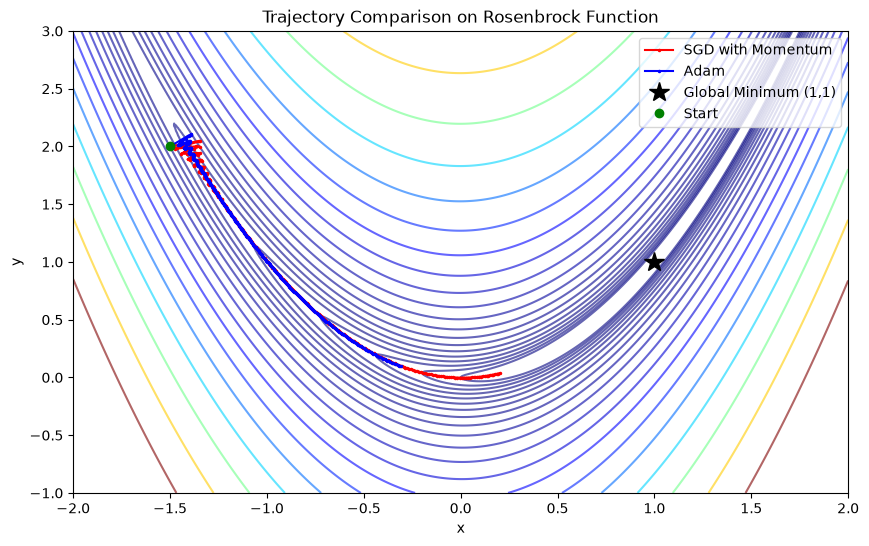

In [2]:
# Configuration
start_point = [-1.5, 2.0]
iters = 300

traj_sgd = sgd_momentum(start_point, lr=0.0005, iterations=iters)
traj_adam = adam(start_point, lr=0.05, iterations=iters)

# Plotting the contours and paths
x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

plt.figure(figsize=(10, 6))
plt.contour(X, Y, Z, levels=np.logspace(0, 3, 20), cmap='jet', alpha=0.6)
plt.plot(traj_sgd[:, 0], traj_sgd[:, 1], 'r.-', label='SGD with Momentum', markersize=3)
plt.plot(traj_adam[:, 0], traj_adam[:, 1], 'b.-', label='Adam', markersize=3)
plt.plot(1, 1, 'k*', markersize=15, label='Global Minimum (1,1)')
plt.plot(start_point[0], start_point[1], 'go', label='Start')

plt.title('Trajectory Comparison on Rosenbrock Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


- **Speed to Low-Loss Region**: Adam reaches the flat valley floor much faster than SGD. Because Adam scales updates by the rolling inverse square root of the gradients ($v_hat$), it takes larger steps in directions where gradients are consistently small.
- **Oscillations**: SGD with Momentum exhibits heavy oscillations when descending down steep valley walls. The accumulated momentum vector carries it past the valley floor, causing it to bounce back and forth across the narrow gap before stabilizing.
- Narrow Valley Trajectories:
  - **SGD** with Momentum slows down significantly once inside the valley. The gradient components cancel each other out sideways, and the forward progress toward (1, 1) relies entirely on a tiny residual gradient along the flat floor.
  - **Adam** scales up its step sizes along the flat valley direction because the historical gradients there are small. However, because it adapts per-parameter, it can exhibit a "zigzag" staircase path inside highly curved non-convex valleys where the optimum direction changes dynamically.

## 12. AdamW: Why Weight Decay Must Be Decoupled

- Problem: overfitting, bad generalisation
- **L2 Regularisation**: Don't just minimise the data loss, minimise this:
  - minimise first term -> fit data well
  - minimise second term -> small weight (large weight causes overfitting)

$$
L(\theta) = L_{\text{data}}(\theta) + \frac{\lambda}{2}\|\theta\|^2
$$

- $\lambda$: controls the strength of the penalty
  - Too large -> underfit
  - Too small -> overfit
- $\|\theta\|^2$: Euclidean norm.
- $\frac{1}{2}$: because

$$
\frac{\partial}{\partial \theta}(\frac{1}{2}\|\theta\|^2) = \theta
$$

Now the gradient:

$$
\nabla L = \nabla L_{\text{data}} + \lambda\theta
$$

**SGD**

then inject $g + \lambda\theta$ into the equations instead of just $g$.

$$
\theta_{t+1} = \theta_{t} - \alpha(g + \lambda\theta_t) = (1 - \alpha\lambda)\theta_t - \alpha g
$$

- The $(1 - \alpha\lambda)\theta_t$ is called **Weight decay**.

**But in Adam**

- Adam memorises history -> the shrinkage depends also on gradient history, not just $\lambda$.

### The core idea of AdamW

- Compute Adam as normal, then apply weight decay after.

$$
\theta \leftarrow \theta - \alpha\frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}
$$

then

$$
\theta \rightarrow (1 - \alpha\lambda)\theta
$$

## 13. Learning Rate Scheduling

- Treat learning rate as a function $\alpha_t = f(t)$
- Early training -> Exploration
- Later training -> Exploitation

### Step Decay

- Change learning rate after a number of epoch

$$
\alpha_t = \alpha_0 \gamma^k
$$

- $\gamma < 1$
- $k$: counts completed milestones
- Easy to implement.
- Too sudden when after a number of epoch.

### Exponential Decay

$$
\alpha_t = \alpha_0e^{-kt} = \alpha_0\gamma^t
$$

- Smoother
- But $\alpha$ will become tiny -> stop training.

### Cosine Annealing

$$
\alpha_t = \alpha_{\min} + \frac{1}{2}(\alpha_{\max} - \alpha_{\min})(1 + \cos\frac{\pi t}{T})
$$

- Much smoother, no sharp change.
- Near convergence -> derivative reaches 0 -> learning rate gently decreases.

### Stochastic Gradient Descent with Warm Restarts (SGDR)

- Restart -> increase learning rate.
- Allow explore another region.

### Learning Rate Warm-up

- This was mentioned in Lesson 12 as a method to avoid Adam's failure due to large learning rate, start with tiny learning rate.

### One-Cycle Policy

- First increase to explore, escape poor regions
- Later decrease to exploit, fine tune, convergence.
- Performs faster than monotonic decay.

### Summary

Which schedule to choose:

| Optimiser             | Common schedule                |
| --------------------- | ------------------------------ |
| SGD                   | Step decay or cosine annealing |
| SGD + Momentum        | Cosine annealing               |
| Adam                  | Warm-up + cosine decay         |
| AdamW                 | Warm-up + cosine decay         |
| Large Language Models | Warm-up + cosine decay         |
| Vision Transformers   | Warm-up + cosine decay         |


> Modern deep learnings choose: Warm-up + cosine decay.

Implement gradient descent on the quadratic function

$$
f(x) = x^2
$$

using four schedules:

1. Constant learning rate.
2. Step decay.
3. Exponential decay.
4. Cosine annealing.

For each schedule:

- Record the learning rate at every iteration.
- Record the parameter trajectory.
- Plot:
  - learning rate vs iteration,
  - loss vs iteration,
  - parameter vs iteration.

Compare:

- Which converges fastest initially?
- Which produces the smoothest final convergence?
- How does the schedule influence overshooting near the minimum?

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def grad_f(x):
    return 2*x

def get_schedules(init_lr, iterations):
    lrs = {
        'Constant': np.full(iterations, init_lr),
        'Step Decay': np.zeros(iterations),
        'Exponential Decay': np.zeros(iterations),
        'Cosine Annealing': np.zeros(iterations)
    }

    for t in range(iterations):
        # Step Decay: drop by half every 15 iterations
        lrs['Step Decay'][t] = init_lr * (.5**(t // 15))

        # Exponential Decay
        lrs['Exponential Decay'][t] = init_lr * (.93 **t)

        # Cosine Annealing
        lrs['Cosine Annealing'][t] = init_lr * 0.5 * (1 + np.cos((np.pi * t)/iterations))

    return lrs

def run_optimization(start_x, iterations=50, init_lr=0.4):
    schedules = get_schedules(init_lr, iterations)
    results = {}
    
    for name, lr_history in schedules.items():
        x_history = [start_x]
        loss_history = [f(start_x)]
        x = start_x
        
        for t in range(iterations):
            lr = lr_history[t]
            x = x - lr * grad_f(x)
            x_history.append(x)
            loss_history.append(f(x))
            
        results[name] = {
            'lr': lr_history,
            'x': np.array(x_history[:-1]), # Match length to iterations
            'loss': np.array(loss_history[:-1])
        }
    return results

In [6]:
results = run_optimization(start_x=10.0, iterations=50, init_lr=0.45)

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
C:\Users\PC\AppData\Local\Temp\ipykernel_16860\3795598732.py:11: SyntaxWarning: invalid escape sequence '\e'
  ylabels = ['Learning Rate ($\eta$)', 'Loss $f(x)$', 'Parameter Value ($x$)']


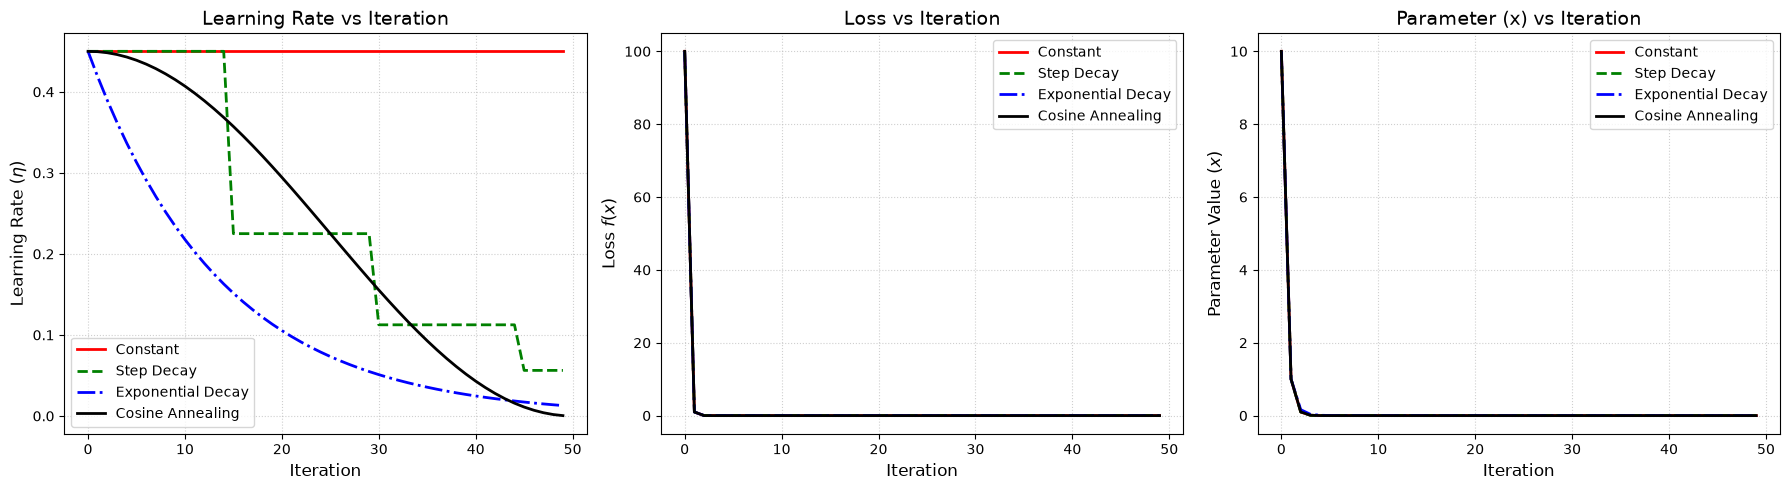

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
styles = {'Constant': 'r-', 'Step Decay': 'g--', 'Exponential Decay': 'b-.', 'Cosine Annealing': 'k-'}

for name, data in results.items():
    axs[0].plot(data['lr'], styles[name], label=name, lw=2)
    axs[1].plot(data['loss'], styles[name], label=name, lw=2)
    axs[2].plot(data['x'], styles[name], label=name, lw=2)

# Graph Adjustments
titles = ['Learning Rate vs Iteration', 'Loss vs Iteration', 'Parameter (x) vs Iteration']
ylabels = ['Learning Rate ($\eta$)', 'Loss $f(x)$', 'Parameter Value ($x$)']

for i in range(3):
    axs[i].set_title(titles[i], fontsize=14)
    axs[i].set_xlabel('Iteration', fontsize=12)
    axs[i].set_ylabel(ylabels[i], fontsize=12)
    axs[i].grid(True, linestyle=':', alpha=0.6)
    axs[i].legend()

plt.tight_layout()
plt.show()


## 14. Modern Optimisers

> Which optimiser makes training at massive scale possible?

### Lion

- Developed by Google.
- Sometimes, we only need direction, not magnitude -> updated learning rate = $-\alpha\text{sign}(m_t)$
- Lesser memory
- But not universally better than AdamW.

In [8]:
import numpy as np

class Lion:
    
    def __init__(self, beta=.9, lr=.01):
        self.beta = beta
        self.lr = lr
        self.m = None

    def step(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(params)

        self.m = self.beta * m + (1 - self.beta) * grads
        params -= self.lr*np.sign(self.m)
        return params

### AdaFactor

- Also developed by Google.
- But instead of storing all elements O(m x n), it only stores statistics of rows + statistics of columns O(m + n)

### LAMB

- Large Batch Optimisation.
- Normalises updates at each layer, which has different scales.

$$
\Delta\theta = \alpha \frac{\|\theta\|}{\|\Delta\|}\Delta
$$

### Shampoo

- Hessian -> Adam's curvature.
- Shampoo: diagonal matrix -> matrix preconditioners
- Updates become:

$$
G^{-1/2}g
$$

- But computing full Hessian is expensive.

### Sophia

- Stochastic estimate rather than computing and storing full Hessian.

$$
\theta \leftarrow \theta - \alpha \frac{g}{\hat{h} + \epsilon}
$$

where $\hat{h}$ is local curvature.

> Adam divides by gradient variance. Sophia divides by curvature.

### Muon

- Doesn't change learning rate. Change geometry of optimisation.

### Comparign modern optimisers

| Optimiser | Main idea                                            | Extra memory | Best suited for                                   |
| --------- | ---------------------------------------------------- | -----------: | ------------------------------------------------- |
| AdamW     | Momentum + adaptive scaling + decoupled weight decay |         High | General-purpose deep learning                     |
| Lion      | Use only the sign of momentum                        |          Low | Memory-efficient training                         |
| AdaFactor | Factorise second-moment estimates                    |     Very low | Extremely large language models                   |
| LAMB      | Layer-wise adaptive scaling                          |         High | Very large batch training                         |
| Shampoo   | Matrix preconditioning                               |    Very high | Faster convergence when computation is affordable |
| Sophia    | Approximate second-order information                 |     Moderate | Faster optimisation with curvature estimates      |
| Muon      | Richer optimisation geometry                         |       Varies | Emerging large-scale training methods             |


### Unifying View

$$
\theta \leftarrow \theta - \alpha P_t d_t
$$

- $d_t$: direction
- $P_t$: preconditioner
- $\alpha$: learning rate or schedule

Then for each optimiser:

- SGD: $P_t = I$
- Momentum: Change $d_t$
- AdamW: diagonal $P_t$
- Shampoo: matrix value $P_t$
- Sophia: curvature-informed $P_t$
- LAMB: layer-wise scaling
- Lion: simplify $d_t$ keep the sign.

### Summary

| Situation                        | Common choice                                        |
| -------------------------------- | ---------------------------------------------------- |
| Small neural networks            | AdamW                                                |
| CNNs                             | SGD + Momentum or AdamW                              |
| Transformers                     | AdamW                                                |
| Very large language models       | AdamW or AdaFactor (depending on memory constraints) |
| Extremely large batch training   | LAMB                                                 |
| Memory-constrained training      | Lion or AdaFactor                                    |
| Research into faster convergence | Shampoo, Sophia, Muon                                |


## 15. Second-Order Optimisation

- How much gradient changes
- Second derivative
- Hessian

### Newton's direction

Given $f(x)$, gradient:

$$
\nabla f(x + \Delta x) = \nabla f(x) + H\Delta x
$$

Minimum at gradient = 0, hence:

$$
\nabla f(x) + H\Delta x = 0 \\
\Leftrightarrow \Delta x = -H^{-1} \nabla f(x)
$$

This is **Newton's direction**.

- It scales direction down if curvature is huge, and stretches that direction if the curvature is tiny.
- Unlike zig-zag gradient descents, Newton points it straight to the minimum thanks to the $H^{-1}$ **undoes the stretching of the loss landscape**.

> Newton's direction is powerful, but I don't really understand why. :((

e.g., $f(x) = x^2$.

- Gradient: $2x$
- Hessian: 2
- Newton update: $x_{\text{new}} = x - \frac{1}{2}2x = 0$ -> straight to the minimum with just one step.

> But it is costly. n params -> $O(n^2)$ for Hessian, $O(n^3)$ for inversion.

Taylor:

$$
f(x + \Delta x) \approx f(x) + \nabla f(x)^T\Delta x + \frac{1}{2}\Delta x^T H \Delta x \\
f'(x + \Delta x) \approx f'(x) + f''(x)\Delta x
$$

By applying a first-order Taylor expansion to the vector-valued function

$$
\nabla f(x + \Delta x) = \nabla f(x) + D(\nabla f)(x)\Delta x = \nabla f(x) + H\Delta x
$$

with $D(\nabla f)(x)$ is exactly Hessian matrix.

In [9]:
import numpy as np

def f(x):
    return x**2

def grad(x):
    return 2 * x

def hessian(x):
    return 2

x = 10.0

print(f"Initial x = {x}")

for i in range(3):
    g = grad(x)
    H = hessian(x)
    x = x - g / H
    print(f"Iteration {i+1}: x = {x:.6f}, f(x) = {f(x):.6f}")

Initial x = 10.0
Iteration 1: x = 0.000000, f(x) = 0.000000
Iteration 2: x = 0.000000, f(x) = 0.000000
Iteration 3: x = 0.000000, f(x) = 0.000000


### Quasi-Newton

- Don't compute Hessian, estimate it.
- DFP
- BFGS
- L-BFGS

**BFGS**

For $s_k = x_{k+1} - x_k$, $y_k = \nabla f_{k+1} - \nabla f_k$. Secant equation:

$$
B_{k+1}s_k = y_K
$$

**L-BFGS**

- Standard BFGS still stores $n \times n$ matrix
- L-BFGS stores only the last $m$ (usually m = 5-20) -> $O(nm)$

### Gauss-Newton

- Suppose objective: $\sum_i r_i^2$.
- Not Hessian, we compute Jacobian: $J^TJ$

### Natural Gradient

> Don't measure distance in parameter space. Measure distance in the space of probability distributions produced by the model.

- $F$: Fisher information matrix
- Instead of $-\nabla f$:

$$
-F^{-1}\nabla f
$$

### Comparison

| Method           | Uses curvature?                | Exact Hessian? | Memory                    | Typical use                            |
| ---------------- | ------------------------------ | -------------- | ------------------------- | -------------------------------------- |
| SGD              | ❌                              | No             | Tiny                      | Deep learning                          |
| Momentum         | ❌                              | No             | Tiny                      | Deep learning                          |
| Adam             | Approximate (diagonal scaling) | No             | Small                     | Most deep learning                     |
| Newton           | ✅                              | Yes            | Massive                   | Small optimisation problems            |
| BFGS             | ✅                              | Approximate    | Large                     | Classical optimisation                 |
| L-BFGS           | ✅                              | Approximate    | Moderate                  | Medium-scale optimisation              |
| Gauss–Newton     | Approximate                    | No             | Moderate                  | Least-squares problems                 |
| Natural Gradient | Information geometry           | Fisher matrix  | Large unless approximated | Research and specialised deep learning |


## 16. Optimisation in Deep Learning Today

### Scaling Laws

$$
L(C) \propto C^{-\alpha}
$$

- $C$: training compute
- $\alpha > 0$: constant depends on the problem.

### Mixed Precision

- Memory problem,
- Don't need 32-bit everywhere. Instead of FP32, use FP16 or BF16

### Distributed Optimisation

- **Data parallelism**: minibatches
- **Model parallelism**: each GPU processes a batch of layers.
- **Pipeline parallelism**: each GPU processes a different stage.

### Minimise Communication Bottleneck

- Gradient compression
- Quantised communication
- Overlapping communication with computation
- Asynchronous updates

### ZeRO Optimisation

- Zero Redundancy Optimiser.
- No replication, partitioning tensors: weights, gradients, momentum, variance.
- 3 stages:
  - stage 1: shard optimiser states (store Adam's m and v)
  - stage 2: shard gradients
  - stage 3: shard model params
- Each GPU owns only a fraction of weights.

### Fused Optimisers

- Combine small operations into a single GPU kernel.

### Checkpointing

- Save only selected activations
- Recompute the rest.

### Summary

| Challenge                          | Solution                         |
| ---------------------------------- | -------------------------------- |
| Zig-zagging                        | Momentum                         |
| Overshooting                       | Momentum, Nesterov               |
| Different parameter scales         | AdaGrad, RMSProp                 |
| Sparse gradients                   | AdaGrad                          |
| Non-stationary gradients           | RMSProp                          |
| Fast convergence                   | Adam                             |
| Weight decay with adaptive methods | AdamW                            |
| Better generalisation              | Lion, SGD (in some regimes)      |
| Curvature                          | Newton, L-BFGS, Natural Gradient |
| Learning dynamics                  | Schedulers                       |
| Memory limits                      | AdaFactor, ZeRO                  |
| Communication limits               | Distributed optimisation         |
| GPU efficiency                     | Fused optimisers                 |
| Numerical stability                | Mixed precision + loss scaling   |
